# MNIST eigendigits via Lanczos

This notebook uses the Lanczos iteration to study how well a Krylov-subspace method approximates the leading eigenspace of a large covariance matrix, compared against a full dense eigendecomposition.

We center a subset of MNIST images to form the $784 \times 784$ covariance matrix $C = \frac{1}{n} X^\top X$. Since $C$ is symmetric by construction, we run Lanczos on $C$ from a random starting vector to build a tridiagonal matrix $T$. We compute the eigenpairs of $T$ via QR iteration and lift the resulting Ritz vectors back to pixel space via

$$v_j = Q w_j$$

Visualizing these leading directions at the pixel level gives the 'eigendigits.'

We vary the Krylov dimension $k$ and the sample size $n$, and compare the leading Lanczos eigendigits against a dense eigensolver applied to the full covariance matrix.

This mirrors a common large-scale setting like PCA / factor estimation on large covariance matrices where a dense $O(d^3)$ eigendecomposition is infeasible and a matrix-free iterative method like Lanczos is used instead.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

from src.eigensolvers import qr_iteration_symmetric
from src.krylov_algorithms import lanczos

In [12]:
# load MNIST 70,000 samples of 28x28 images
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_full = mnist['data'].astype(float) # shape (70000, 784)
y_full = mnist['target'].astype(int) # digits 0–9 as integers

print(f'full MNIST shape {X_full.shape}, {y_full.shape}')
n_samples = 30000
X = X_full[:n_samples]
y = y_full[:n_samples]

mean_image = X.mean(axis=0)
X_centered = X - mean_image

n, d = X_centered.shape  # n samples, d = 784 pixels
C = (X_centered.T @ X_centered) / n  # d x d covariance matrix

print(f'subset covariance matrix shape {C.shape}')

full MNIST shape (70000, 784), (70000,)
subset covariance matrix shape (784, 784)


Below, we apply the Lanczos algorithm to the covariance matrix $C$ with Krylov dimension $k = 20$, then recover the Ritz values/vectors from the resulting tridiagonal matrix via QR iteration.

In [13]:
rng = np.random.default_rng(0)
b = rng.standard_normal(d)

k = 20 # krylov dimension and number of lanczos steps
Q_l, T_l, alpha, beta = lanczos(C, b, k_max=k)

symQR_result = qr_iteration_symmetric(T_l, shifted=True, maxit=500)
T_schur, Q_tri, = symQR_result.T, symQR_result.Q
theta = np.diag(T_schur)
W = Q_tri

idx = np.argsort(theta)[::-1]
theta = theta[idx]
W = W[:, idx]

# lift Ritz vectors back to pixel space v_j = Q_l @ w_j
V = Q_l @ W
eigenvalues = theta

plotting helper for the eigendigits that converts principal components back to pixels

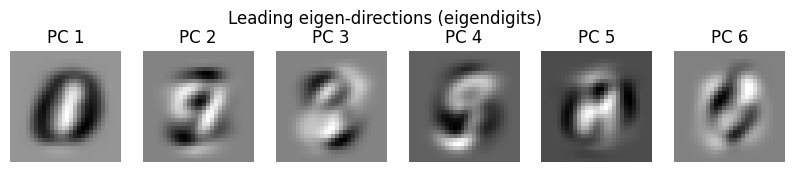

In [14]:
def show_eigendigits(V: np.ndarray, num=6):
    '''
    V : np.ndarray (d, k) 
        array of eigenvectors
    num : int
        how many leading eigendigits to plot
    '''
    plt.figure(figsize=(10, 2))
    for i in range(num):
        eigvec = V[:, i]

        img = eigvec.reshape(28, 28)

        plt.subplot(1, num, i + 1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(f'PC {i+1}')
    plt.suptitle('Leading eigen-directions (eigendigits)')
    plt.show()
    plt.close('all')

show_eigendigits(V, num=6)


number of images used: 10000


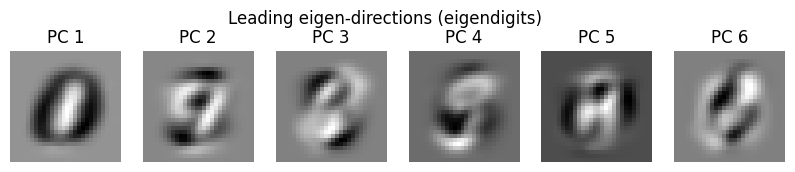

number of images used: 20000


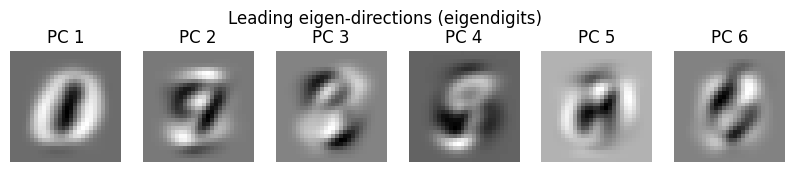

number of images used: 40000


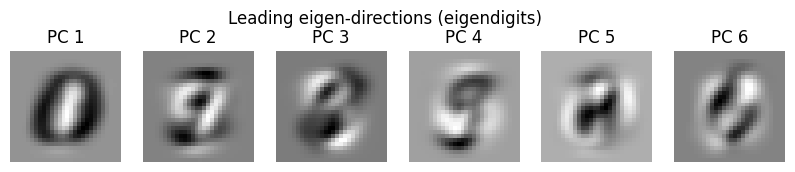

number of images used: 60000


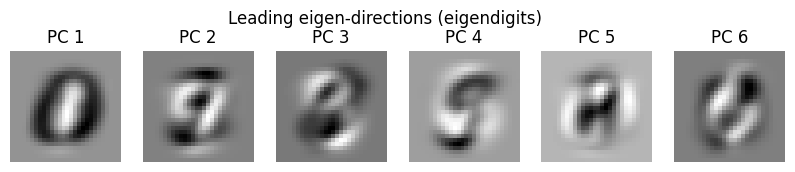

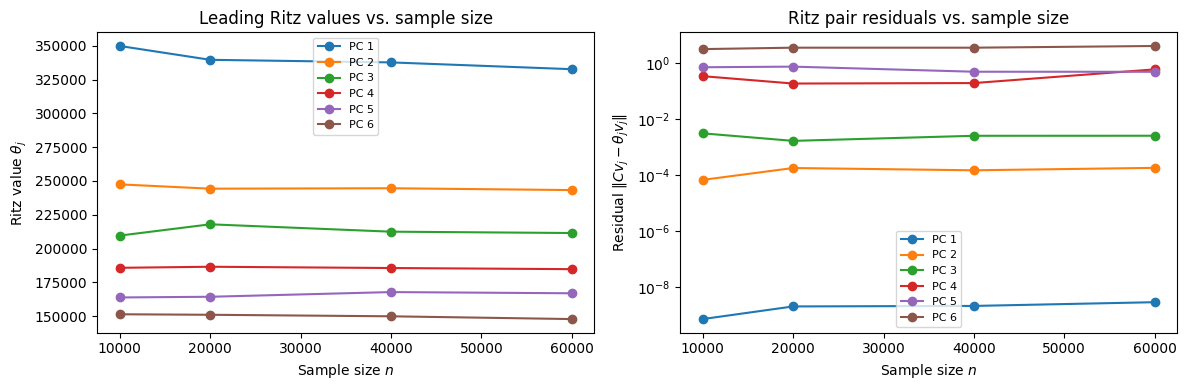

In [15]:
# try with different sample sizes
sample_sizes = [10000, 20000, 40000, 60000]

ritz_history_n = []
resid_history_n = []

for n_samples in sample_sizes:
    X = X_full[:n_samples]
    y = y_full[:n_samples]

    # center data
    mean_image = X.mean(axis=0)
    X_centered = X - mean_image

    n, d = X_centered.shape
    C = (X_centered.T @ X_centered) / n

    k = 20
    Q_l, T_l, alpha, beta = lanczos(C, b, k_max=k)

    symQR_result = qr_iteration_symmetric(T_l, shifted=True, maxit=500)
    T_schur, Q_tri, = symQR_result.T, symQR_result.Q
    theta = np.diag(T_schur)
    W = Q_tri

    idx = np.argsort(theta)[::-1]
    theta = theta[idx]
    W = W[:, idx]

    V = Q_l @ W
    eigenvalues = theta

    residuals_n = [np.linalg.norm(C @ V[:, j] - eigenvalues[j] * V[:, j]) for j in range(6)]
    ritz_history_n.append(eigenvalues[:6].copy())
    resid_history_n.append(residuals_n)

    print(f'number of images used: {n_samples}')
    show_eigendigits(V, num=6)

ritz_history_n = np.array(ritz_history_n)
resid_history_n = np.array(resid_history_n)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for j in range(6):
    axes[0].plot(sample_sizes, ritz_history_n[:, j], marker='o', label=f'PC {j+1}')
axes[0].set_xlabel('Sample size $n$')
axes[0].set_ylabel('Ritz value $\\theta_j$')
axes[0].set_title('Leading Ritz values vs. sample size')
axes[0].legend(fontsize=8)

for j in range(6):
    axes[1].plot(sample_sizes, resid_history_n[:, j], marker='o', label=f'PC {j+1}')
axes[1].set_yscale('log')
axes[1].set_xlabel('Sample size $n$')
axes[1].set_ylabel(r'Residual $\|Cv_j - \theta_j v_j\|$')
axes[1].set_title('Ritz pair residuals vs. sample size')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Krylov space size: 20


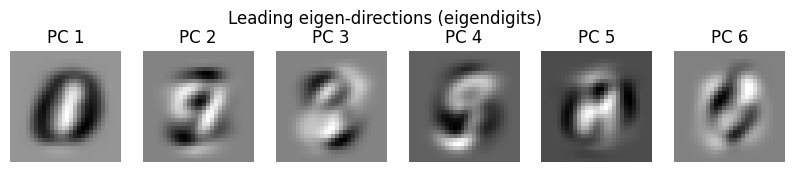

Krylov space size: 40


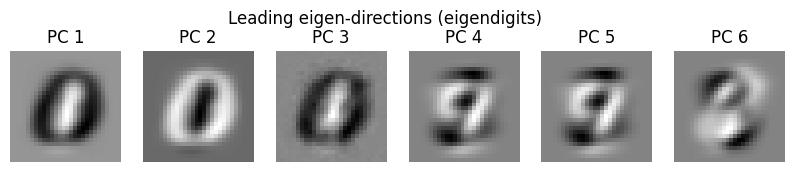

Krylov space size: 60


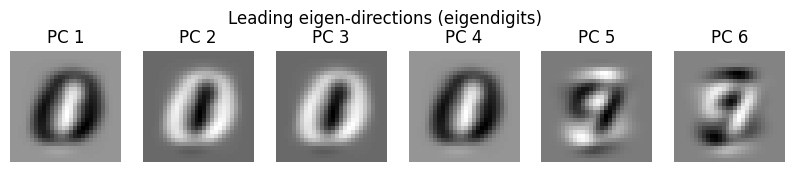

Krylov space size: 80


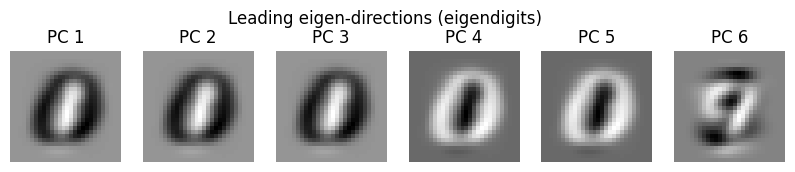

Krylov space size: 100


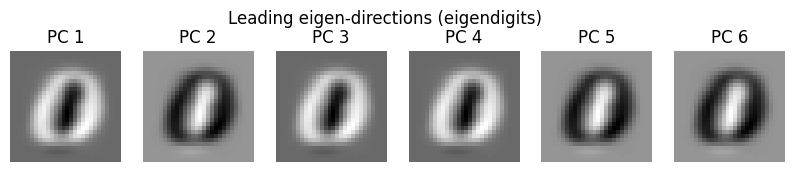

Krylov space size: 200


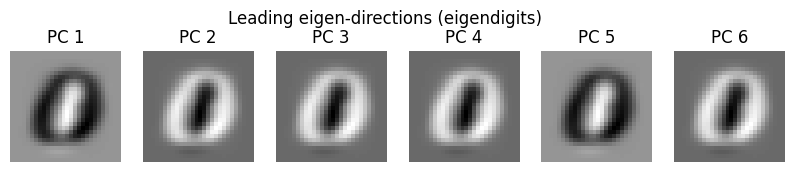

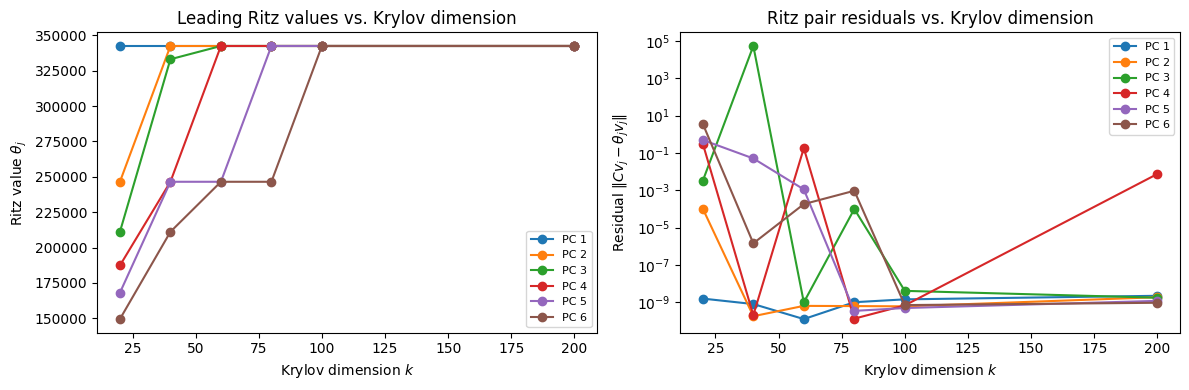

In [16]:
# try with different krylov dimensions and thus number of lancsoz steps
k_values = [20, 40, 60, 80, 100, 200]

ritz_history_k = []
resid_history_k = []

for k in k_values:
    n_samples = 30000
    X = X_full[:n_samples]
    y = y_full[:n_samples]

    mean_image = X.mean(axis=0)
    X_centered = X - mean_image

    n, d = X_centered.shape
    C = (X_centered.T @ X_centered) / n

    Q_l, T_l, alpha, beta = lanczos(C, b, k_max=k)

    symQR_result = qr_iteration_symmetric(T_l, shifted=True, maxit=500)
    T_schur, Q_tri, = symQR_result.T, symQR_result.Q
    theta = np.diag(T_schur)
    W = Q_tri

    idx = np.argsort(theta)[::-1]
    theta = theta[idx]
    W = W[:, idx]

    V = Q_l @ W
    eigenvalues = theta

    residuals_k = [np.linalg.norm(C @ V[:, j] - eigenvalues[j] * V[:, j]) for j in range(6)]
    ritz_history_k.append(eigenvalues[:6].copy())
    resid_history_k.append(residuals_k)

    print(f'Krylov space size: {k}')
    show_eigendigits(V, num=6)

ritz_history_k = np.array(ritz_history_k)
resid_history_k = np.array(resid_history_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for j in range(6):
    axes[0].plot(k_values, ritz_history_k[:, j], marker='o', label=f'PC {j+1}')
axes[0].set_xlabel('Krylov dimension $k$')
axes[0].set_ylabel('Ritz value $\\theta_j$')
axes[0].set_title('Leading Ritz values vs. Krylov dimension')
axes[0].legend(fontsize=8)

for j in range(6):
    axes[1].plot(k_values, resid_history_k[:, j], marker='o', label=f'PC {j+1}')
axes[1].set_yscale('log')
axes[1].set_xlabel('Krylov dimension $k$')
axes[1].set_ylabel(r'Residual $\|Cv_j - \theta_j v_j\|$')
axes[1].set_title('Ritz pair residuals vs. Krylov dimension')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

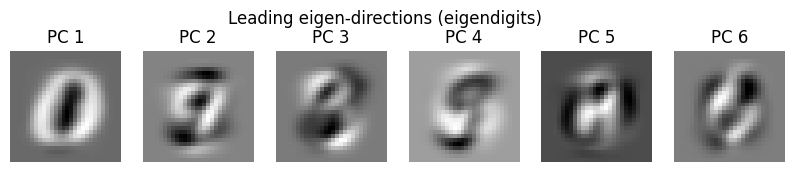

lanczos ritz values - dense eigenvalues [7.47719461e-15 3.89510681e-01 6.22388674e-01 8.28678257e-01
 1.03824707e+00 1.29232069e+00]
principal angle between leading Lanczos subspace and dense subspace [2.44948974e+00 3.34863929e-11 2.05176900e-15 1.96296262e-15
 6.19231340e-16 2.47052718e-16]


In [ ]:
# dense eigensolver on C
n_samples = 30000
X = X_full[:n_samples]
y = y_full[:n_samples]

mean_image = X.mean(axis=0)
X_centered = X - mean_image

n, d = X_centered.shape
C = (X_centered.T @ X_centered) / n

result = qr_iteration_symmetric(C, shifted=True, maxit=500)
T = result.T
A_diag = result.T
Q = result.Q

evals = np.diag(A_diag)

idx = np.argsort(evals)[::-1]
evals = evals[idx]
Q = Q[:, idx]

show_eigendigits(Q, num=6)

eigval_error = np.abs(theta[:6] - evals[:6]) / np.abs(evals[:6])
cos_angles = np.linalg.svd(V[:, :6].T @ Q[:, :6], compute_uv=False)

print(f'lanczos ritz values - dense eigenvalues {eigval_error}')
print(f'principal angle between leading Lanczos subspace and dense subspace {cos_angles}')

Across sample sizes and Krylov dimensions, the dominant recovered directions consistently resemble closed loops (top and/or bottom), producing eigendigits that visually resemble 0, 8, and 9, consistent with loops being among the most common strokes across handwritten digits. Varying the sample size ($n = 10\text{k}$–$60\text{k}$) has little qualitative effect beyond a modest reduction in visual noise as $n$ grows; it does not change which directions dominate. Varying the Krylov dimension $k$, however, reveals a clear failure mode. At $k=20$ the six leading eigendigits are sharp and visually distinct. As $k$ increases, the Ritz values for PC2–PC6 climb and merge one by one into the same plateau already occupied by PC1 — PC2 has converged onto PC1's eigenvalue by $k=40$, PC3 by around $k=60$, and by $k=100$ all six Ritz values coincide, each with a residual $\|Cv_j - \theta_j v_j\|$ as small as PC1's (~$10^{-9}$). Correspondingly, the eigendigits at large $k$ collapse into six nearly identical copies of the same tilted-loop ('0') pattern rather than resolving six distinct directions. This is the classic ghost/spurious-eigenvalue behavior of plain Lanczos without reorthogonalization. Rounding error lets the algorithm repeatedly rediscover the same dominant eigenvector instead of new ones as $k$ grows, so more iterations degrade rather than improve the set of recovered leading eigendigits, even though the single top eigenpair remains accurately converged throughout.

### Class conditional eigendigits

We repeat the covariance and lanczos procedure only for a single digit.  This reveals the main modes of variation within that class.

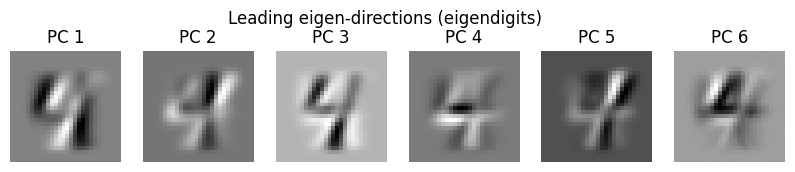

In [18]:
digit = 4
X_digit = X_full[y_full == digit].astype(float)

mean_digit = X_digit.mean(axis=0)
Xd = X_digit - mean_digit

C_d = (Xd.T @ Xd) / Xd.shape[0]

b = np.random.default_rng(1).standard_normal(784)
num_pcs = 15
Q_d, T_d, alpha_d, beta_d = lanczos(C_d, b, k_max=num_pcs)

symQR_result = qr_iteration_symmetric(T_d, shifted=True, maxit=500)
T_schur_d, Q_tri_d = symQR_result.T, symQR_result.Q
vals_d = np.diag(T_schur_d)
vecs_d = Q_tri_d

idx = np.argsort(vals_d)[::-1]
vals_d = vals_d[idx]
vecs_d = vecs_d[:, idx]

V_d = Q_d @ vecs_d

show_eigendigits(V_d, num=6)


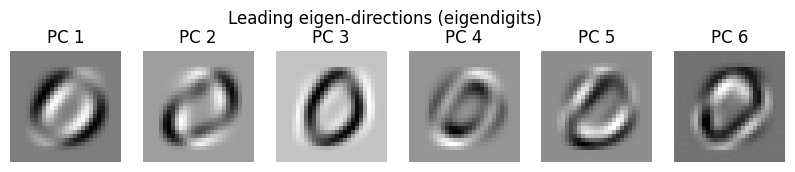

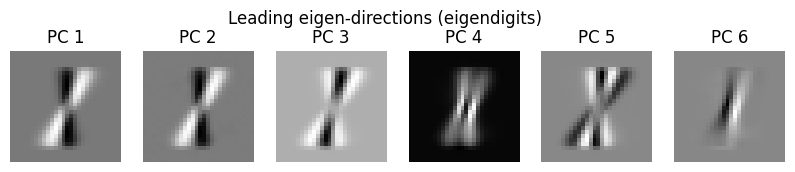

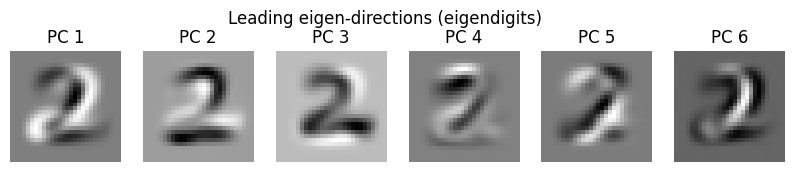

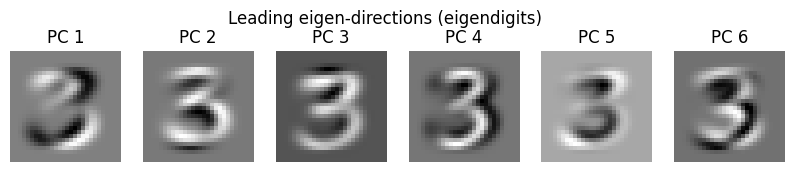

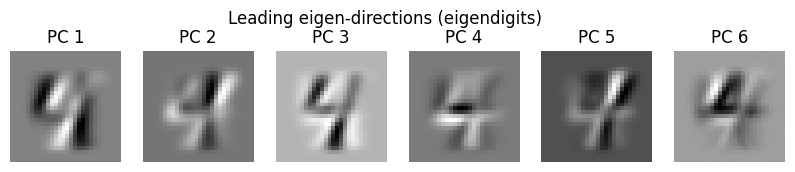

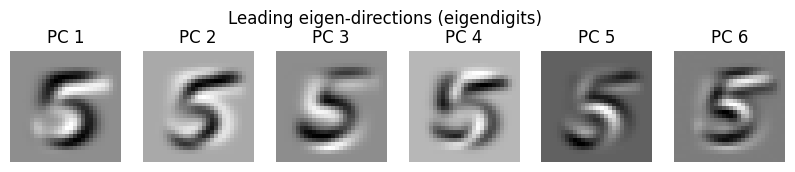

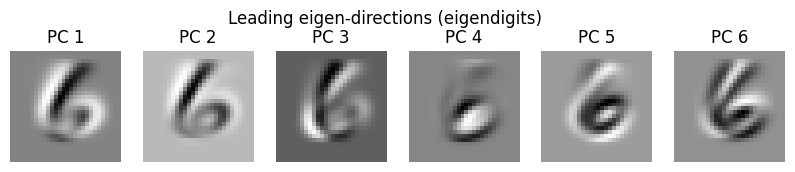

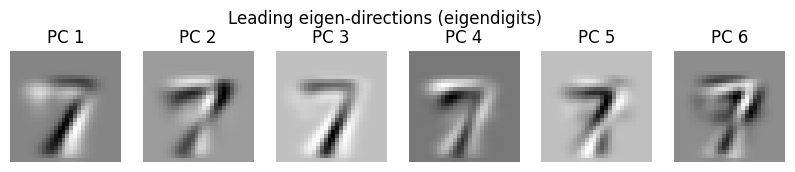

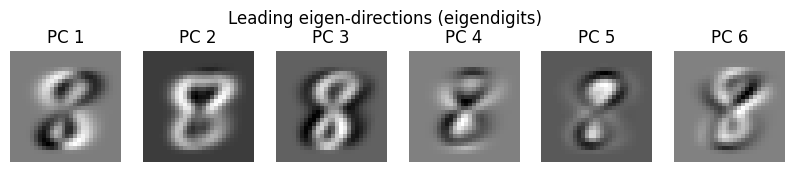

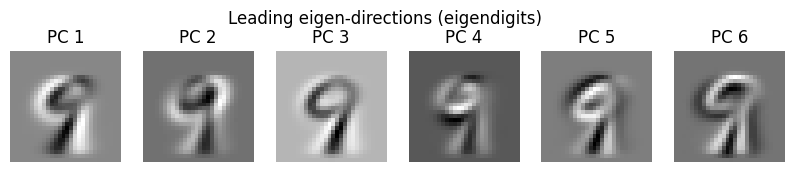

In [19]:
# all digits
digits = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

for digit in digits:

    X_digit = X_full[y_full == digit].astype(float)

    mean_digit = X_digit.mean(axis=0)
    Xd = X_digit - mean_digit

    C_d = (Xd.T @ Xd) / Xd.shape[0]

    b = np.random.default_rng(1).standard_normal(784)
    num_pcs = 15
    Q_d, T_d, alpha_d, beta_d = lanczos(C_d, b, k_max=num_pcs)

    if qr_iteration_symmetric is not None:
        symQR_result = qr_iteration_symmetric(T_d, shifted=True, maxit=500)
        T_schur_d, Q_tri_d = symQR_result.T, symQR_result.Q
        vals_d = np.diag(T_schur_d)
        vecs_d = Q_tri_d
    else:
        vals_d, vecs_d = np.linalg.eigh(T_d)

    idx = np.argsort(vals_d)[::-1]
    vals_d = vals_d[idx]
    vecs_d = vecs_d[:, idx]

    V_d = Q_d @ vecs_d

    show_eigendigits(V_d, num=6)

Across all ten digit classes, the leading within-class PCs consistently highlight two things: The regions where strokes typically start and end, which tend to be highly variable across images, and the digit's core structural strokes. For example, for the digit 7, the leading PCs capture variation in the horizontal top bar and the slanted vertical stroke. Later PCs are visibly noisier and correspond to finer variation such as stroke thickness and small local perturbations near loops or stroke endpoints, rather than large-scale shape variation.